# SARIMAX - 03: Analise de previsoes e residuos
**Grupo 1 | Bitcoin diário**

Este notebook reproduz o walk-forward do notebook 02 e analisa os resíduos fora da amostra. Ele é independente e não depende de arquivos intermediários: carrega treino/teste existentes usando `pathlib`, aplica os hiperparâmetros selecionados no notebook 01 e gera gráficos, estatísticas e o teste de Ljung-Box em memória.


In [1]:
# Reproducao do walk-forward para manter o notebook independente e sem artefatos novos.
import json
import warnings
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
SARIMAX_ORDER = (0, 0, 1)
SARIMAX_SEASONAL_ORDER = (0, 0, 0, 7)
MAXITER = 50

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 11
})

cwd = Path.cwd().resolve()
root_candidates = list(cwd.parents) + [cwd]
root_candidates += [parent / 'analyses' / 'grupo1' for parent in [cwd, *cwd.parents]]
GROUP_ROOT = next(
    (candidate for candidate in dict.fromkeys(root_candidates)
     if (candidate / '01_dados' / 'feature_metadata.json').is_file()),
    None
)
if GROUP_ROOT is None:
    raise FileNotFoundError('Nao foi possivel localizar analyses/grupo1/01_dados/feature_metadata.json.')

DATA_DIR = GROUP_ROOT / '01_dados'
with (DATA_DIR / 'feature_metadata.json').open('r', encoding='utf-8') as file:
    metadata = json.load(file)
FEATURE_COLS = metadata['feature_cols']
TARGET_COL = metadata['target_col']
train = pd.read_csv(DATA_DIR / 'bitcoin_features_train.csv', parse_dates=['date']).sort_values('date').set_index('date')
test = pd.read_csv(DATA_DIR / 'bitcoin_features_test.csv', parse_dates=['date']).sort_values('date').set_index('date')
X_train = train[FEATURE_COLS].astype(float)
y_train = train[TARGET_COL].astype(float)
X_test = test[FEATURE_COLS].astype(float)
y_test = test[TARGET_COL].astype(float)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLS)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=FEATURE_COLS)
y_train_model = y_train.reset_index(drop=True)
y_test_model = y_test.reset_index(drop=True)

state = SARIMAX(
    endog=y_train_model,
    exog=X_train_scaled,
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEASONAL_ORDER,
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=MAXITER)

started_at = perf_counter()
predictions = []
for step in range(len(X_test)):
    next_index = pd.RangeIndex(len(y_train) + step, len(y_train) + step + 1)
    exog_step = X_test_scaled.iloc[[step]].set_axis(next_index)
    target_step = y_test_model.iloc[[step]].set_axis(next_index)
    predictions.append(float(state.get_forecast(steps=1, exog=exog_step).predicted_mean.iloc[0]))
    state = state.append(endog=target_step, exog=exog_step, refit=False)
walkforward_seconds = perf_counter() - started_at

residuals = y_test.to_numpy() - np.asarray(predictions)
df_preds = pd.DataFrame({
    'date': test.index,
    'target_date': test.index + pd.Timedelta(days=1),
    'priceClose_real': y_test.to_numpy(),
    'priceClose_pred_SARIMAX': predictions,
    'residuo_SARIMAX': residuals
})
mae = mean_absolute_error(y_test, predictions)
rmse = float(np.sqrt(mean_squared_error(y_test, predictions)))
print(f'Previsoes: {len(df_preds)} | MAE: USD {mae:,.2f} | RMSE: USD {rmse:,.2f}')
print(f'Tempo walk-forward: {walkforward_seconds:.2f} s')
display(df_preds.head())

Previsoes: 856 | MAE: USD 1,590.77 | RMSE: USD 2,130.91
Tempo walk-forward: 20.60 s


,date,target_date,priceClose_real,priceClose_pred_SARIMAX,residuo_SARIMAX
0,2024-05-08,2024-05-09,63049.959257,60415.681464,2634.277793
1,2024-05-09,2024-05-10,60792.776791,62670.270384,-1877.493594
2,2024-05-10,2024-05-11,60793.709599,59938.661407,855.048192
3,2024-05-11,2024-05-12,61448.394672,60627.792933,820.601739
4,2024-05-12,2024-05-13,62901.447455,60621.911692,2279.535763


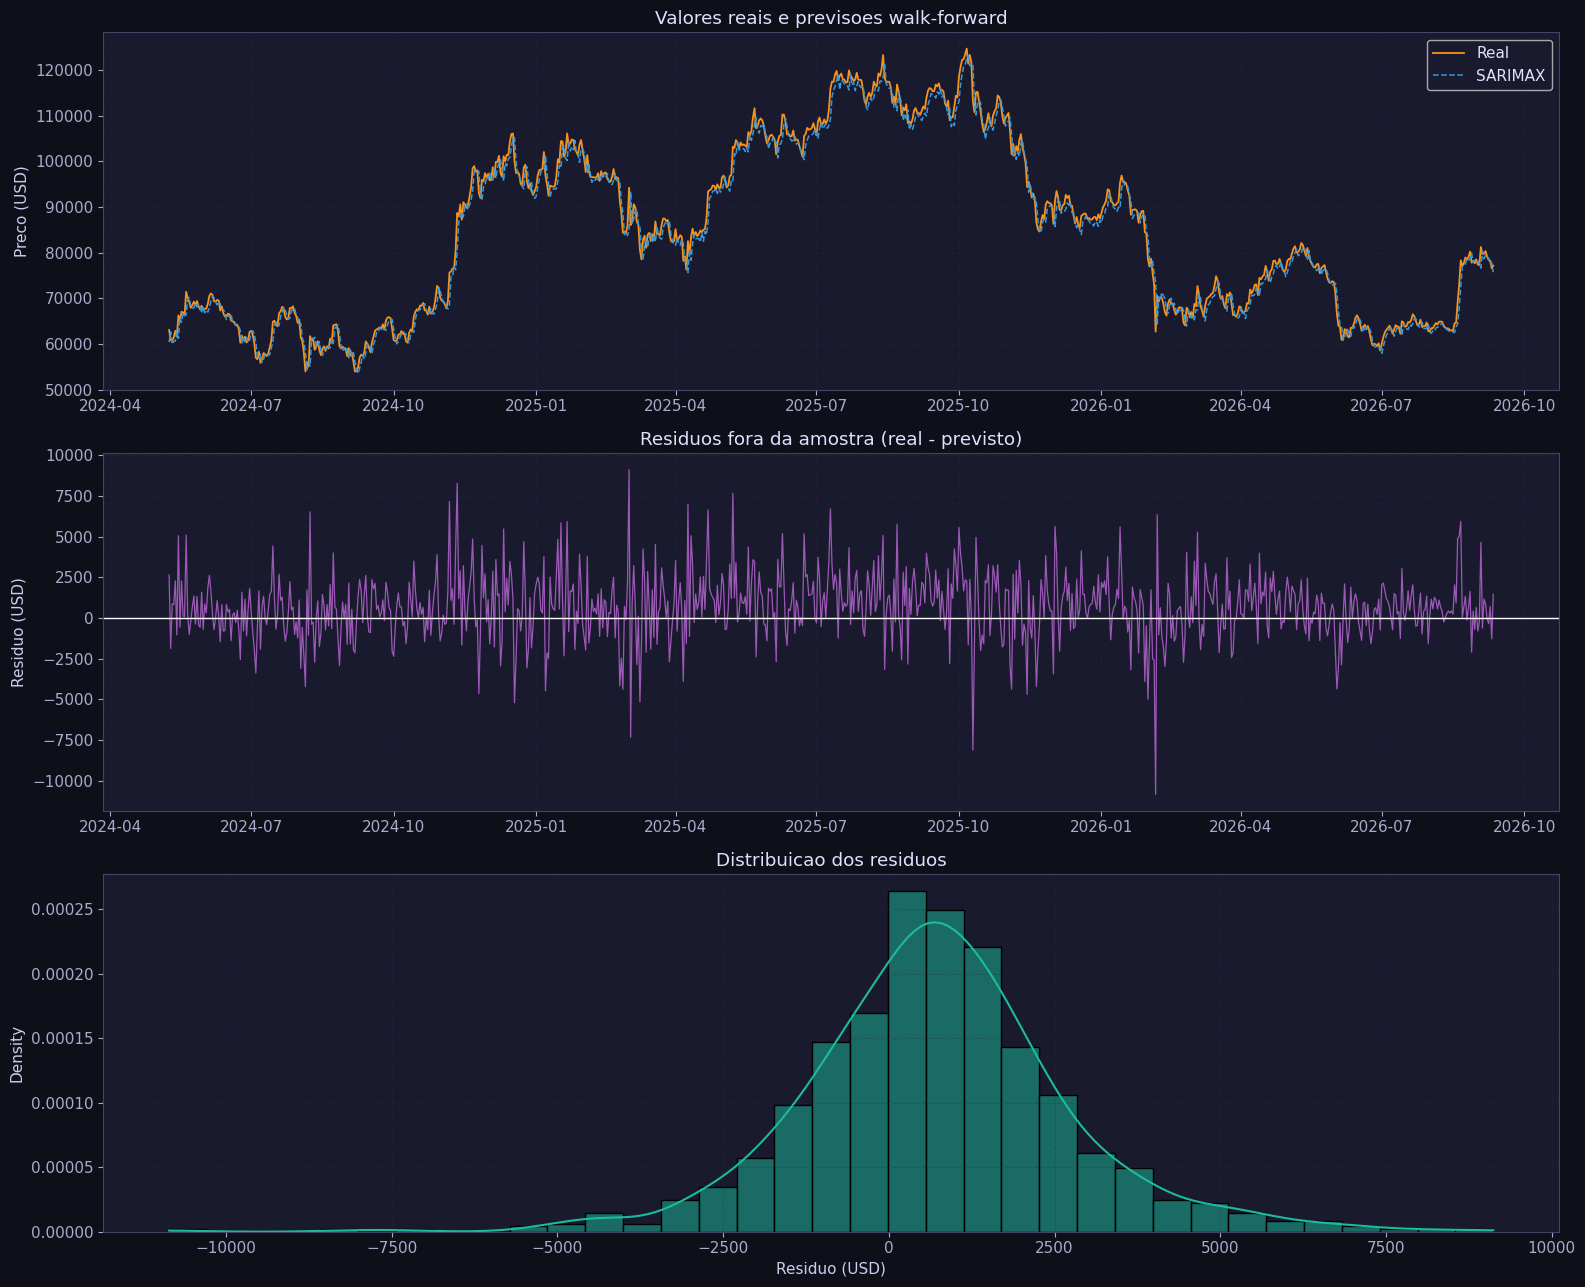

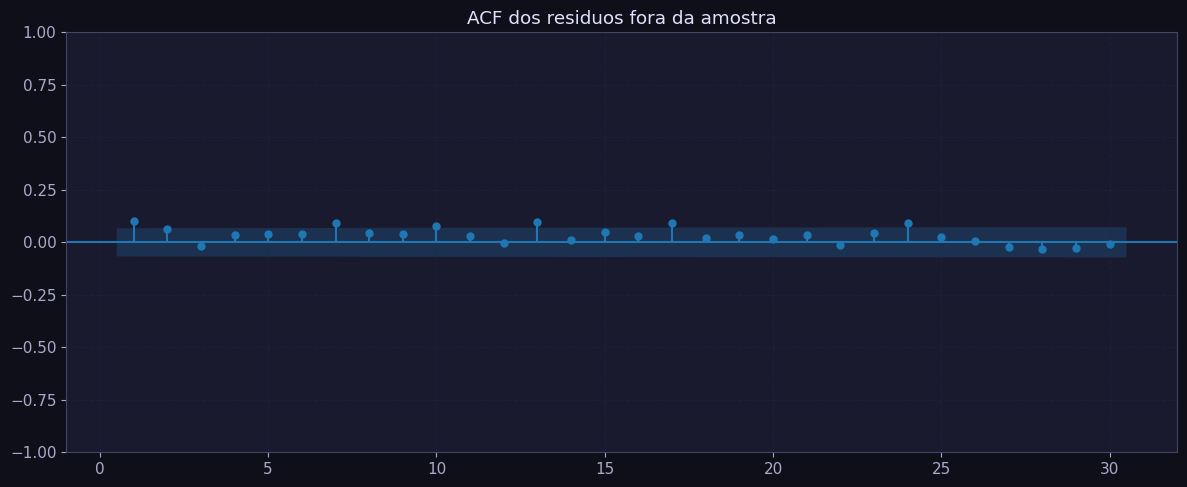

Viés médio: USD 693.86
Desvio padrão dos resíduos: USD 2,015.96
Teste t para média zero: estatística=10.070, p-valor=1.289e-22
Jarque-Bera: estatística=261.594, p-valor=1.569e-57

Teste de Ljung-Box (H0: ausencia de autocorrelacao ate o lag indicado):


,lb_stat,lb_pvalue
7,23.607327,0.001335
14,40.824867,0.000190
30,65.660996,0.000180


Conclusao: rejeita-se H0 em ao menos um lag; permanecem padroes temporais nos residuos.


In [2]:
res = df_preds['residuo_SARIMAX']

fig, axes = plt.subplots(3, 1, figsize=(16, 13), facecolor='#0f0f1a')
axes[0].plot(df_preds['target_date'], df_preds['priceClose_real'], color='#f7931a', lw=1.3, label='Real')
axes[0].plot(df_preds['target_date'], df_preds['priceClose_pred_SARIMAX'], color='#3498db', lw=1.1, ls='--', label='SARIMAX')
axes[0].set_title('Valores reais e previsoes walk-forward', color='#e0e0ff')
axes[0].set_ylabel('Preco (USD)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(df_preds['target_date'], res, color='#9b59b6', lw=0.9)
axes[1].axhline(0, color='white', lw=1)
axes[1].set_title('Residuos fora da amostra (real - previsto)', color='#e0e0ff')
axes[1].set_ylabel('Residuo (USD)')
axes[1].grid(True, alpha=0.3)

sns.histplot(res, kde=True, ax=axes[2], color='#1abc9c', stat='density', bins=35)
axes[2].set_title('Distribuicao dos residuos', color='#e0e0ff')
axes[2].set_xlabel('Residuo (USD)')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5), facecolor='#0f0f1a')
plot_acf(res, lags=30, alpha=0.05, zero=False, ax=ax, title='ACF dos residuos fora da amostra')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ljung_box = acorr_ljungbox(res, lags=[7, 14, 30], return_df=True)
mean_residual = float(res.mean())
std_residual = float(res.std())
t_stat, t_pvalue = stats.ttest_1samp(res, popmean=0)
jb_stat, jb_pvalue = stats.jarque_bera(res)

print(f'Viés médio: USD {mean_residual:,.2f}')
print(f'Desvio padrão dos resíduos: USD {std_residual:,.2f}')
print(f'Teste t para média zero: estatística={t_stat:.3f}, p-valor={t_pvalue:.4g}')
print(f'Jarque-Bera: estatística={jb_stat:.3f}, p-valor={jb_pvalue:.4g}')
print('\nTeste de Ljung-Box (H0: ausencia de autocorrelacao ate o lag indicado):')
display(ljung_box)

if (ljung_box['lb_pvalue'] < 0.05).any():
    print('Conclusao: rejeita-se H0 em ao menos um lag; permanecem padroes temporais nos residuos.')
else:
    print('Conclusao: nao se rejeita H0 nos lags testados; nao ha evidencia estatistica de autocorrelacao residual ate esses lags.')